In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve, f1_score, confusion_matrix
import shap

In [2]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

print("Размер датасета:", df.shape)
print("\nПервые 5 строк:")
print(df.head())
print("\nИнформация о данных:")
print(df.info())
print("\nСтатистика:")
print(df.describe())

Размер датасета: (7043, 21)

Первые 5 строк:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport Str

Датасет содержит 7043 записи и 21 признак.  
У признак TotalCharges (общая сумма платежей) тип object, а должен быть числовой.  
Признак customerID является уникальным, поэтому удалим его перед обучением.
Целевая переменная Churn - тип object, значит надо бинарно закодировать.

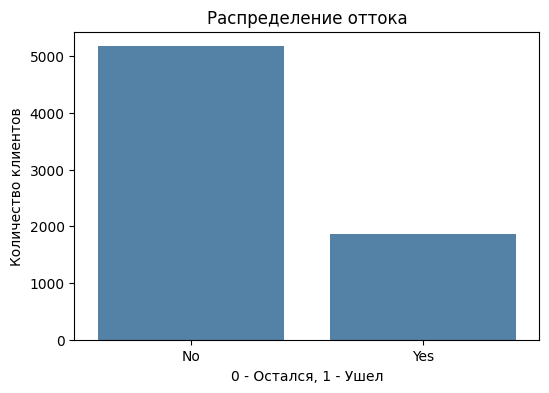

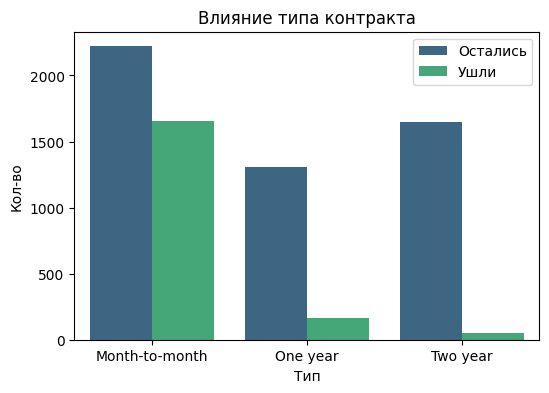

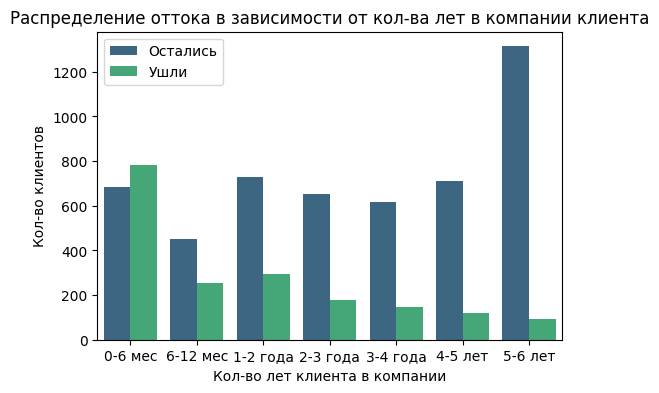

<Axes: >

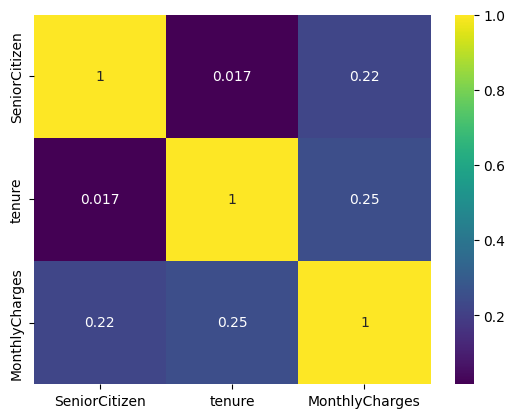

In [3]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Churn', color='steelblue')
plt.title('Распределение оттока')
plt.xlabel('0 - Остался, 1 - Ушел')
plt.ylabel('Количество клиентов')
plt.show()

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Contract', hue='Churn', palette='viridis')
plt.title('Влияние типа контракта')
plt.xlabel('Тип')
plt.ylabel('Кол-во')
plt.legend(['Остались', 'Ушли'])
plt.show()

plt.figure(figsize=(6, 4))
df['tenure_group'] = pd.cut(df['tenure'], bins=[0, 6, 12, 24, 36, 48, 60, 72], labels=['0-6 мес', '6-12 мес', '1-2 года', '2-3 года', '3-4 года', '4-5 лет', '5-6 лет'])
sns.countplot(data=df, x='tenure_group', hue='Churn', palette='viridis')
plt.title('Распределение оттока в зависимости от кол-ва лет в компании клиента')
plt.xlabel('Кол-во лет клиента в компании')
plt.ylabel('Кол-во клиентов')
plt.legend(['Остались', 'Ушли'])
plt.show()
df.drop(['tenure_group'], axis=1, inplace=True)

numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='viridis')

Доля оттока составляет 26.5%. Присутствует дисбаланс классов, следовательно использование метрики Accuracy будет неинформативным, поэтому рассмотрим такие метрики, как F1-score (среднее гармоническое между Precision и Recall) и ROC-AUC.   
Клиенты с помесячной оплатой (Month-to-month) уходят значительно чаще, чем клиенты с годовыми или двухлетними контрактами.  
Срок обслуживания - tenure. Клиенты, которые пользуются услугами менее 12 месяцев, наиболее веротяно покинуть компанию.  
Также можно увидеть высокую корреляцию между tenure и TotalCharges, то есть чем дольше клиент, тем больше общая сумма. Возможна мультиколлинеарность, но для линейных моделей применю масштабирование, а для деревьев это не важно.

In [4]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

df.drop(['customerID'], axis=1, inplace=True)

categorical_cols = df.select_dtypes(include=['object']).columns
print("Категориальные признаки:", categorical_cols.tolist())

Категориальные признаки: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [5]:
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("Размер после кодирования:", df_encoded.shape)

X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

print("Распределение целевой переменной:")
print(y.value_counts())
print(f"Доля оттока: {y.mean():.2%}")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Размер после кодирования: (7043, 31)
Распределение целевой переменной:
Churn
0    5174
1    1869
Name: count, dtype: int64
Доля оттока: 26.54%


Пропуски в TotalCharges заполнены медианой, так как медиана более устойчива к выбросам, чем среднее значение.  
Категориальные признаки закодированы с помощью One-Hot Encoding.  
Данные разделены на train и test выборки в пропорции 70/30 с использованием параметра stratify=y для сохранения исходного распределения классов оттока в обеих выборках.  
Для Logistic Regression было применено масштабирование признаков StandardScaler, так как она чувствительна к разным масштабам данных. Ансамблевые модели (Random Forest, XGBoost) масштабирования не требуют.

In [6]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=300),
    'XGBoost': XGBClassifier(random_state=42, n_estimators=300, eval_metric='logloss')
}

results = {}

for name, model in models.items():
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    results[name] = {
        'F1': f1,
        'ROC-AUC': roc_auc,
        'y_pred': y_pred,
        'y_prob': y_prob
    }

    print(f"\n{name}:")
    print(f"F1 Score: {f1:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

best_model_name = max(results, key=lambda x: results[x]['F1'])
print(f"Лучшая модель: {best_model_name}")


Logistic Regression:
F1 Score: 0.6100
ROC-AUC: 0.8447

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1552
           1       0.67      0.56      0.61       561

    accuracy                           0.81      2113
   macro avg       0.76      0.73      0.74      2113
weighted avg       0.80      0.81      0.80      2113


Random Forest:
F1 Score: 0.5475
ROC-AUC: 0.8234

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1552
           1       0.62      0.49      0.55       561

    accuracy                           0.79      2113
   macro avg       0.73      0.69      0.70      2113
weighted avg       0.77      0.79      0.78      2113


XGBoost:
F1 Score: 0.5257
ROC-AUC: 0.8050

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.86      0.84      1552
           1      

У Logistic Regression наилучший результат - F1 = 0.61, ROC-AUC = 0.84. Следовательно, признаки имеют хорошую линейную разделимость.  
Random Forest и XGBoost показали менее хорошие результаты, так как задача имеет относительно небольшим объемом данных и большим количеством разреженных признаков (после One-Hot Encoding), когда деревья склонны к переобучению на шумах.


Оптимальный порог: 0.2884
F1 при оптимальном пороге: 0.6308


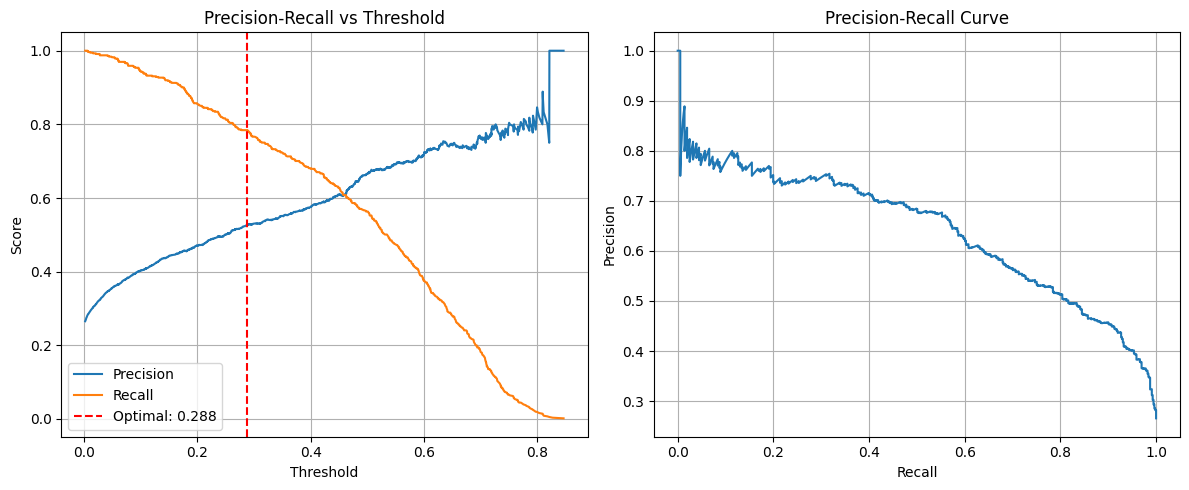

In [10]:
precision, recall, thresholds = precision_recall_curve(y_test, results[best_model_name]['y_prob'])

f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]

print(f"\nОптимальный порог: {optimal_threshold:.4f}")
print(f"F1 при оптимальном пороге: {f1_scores[optimal_idx]:.4f}")

y_pred_optimal = (results[best_model_name]['y_prob'] >= optimal_threshold).astype(int)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.axvline(optimal_threshold, color='red', linestyle='--', label=f'Optimal: {optimal_threshold:.3f}')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall vs Threshold')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(True)

plt.tight_layout()
plt.show()

Стандартный порог вероятности 0.5 не оптимален для задач с дисбалансом классов.
Сдвиг порога до 0.2884 позволил увеличить F1-score с 0.6100 до 0.6308.    
Снижение порога означает, что модель будет чаще предсказывать отток (увеличится Recall). Это приведет к росту количества ложноположительных срабатываний (то есть нахождение лояльных клиентов, которые не собираются уходить), но позволит найти больше клиентов, которые действительно собирались уйти.

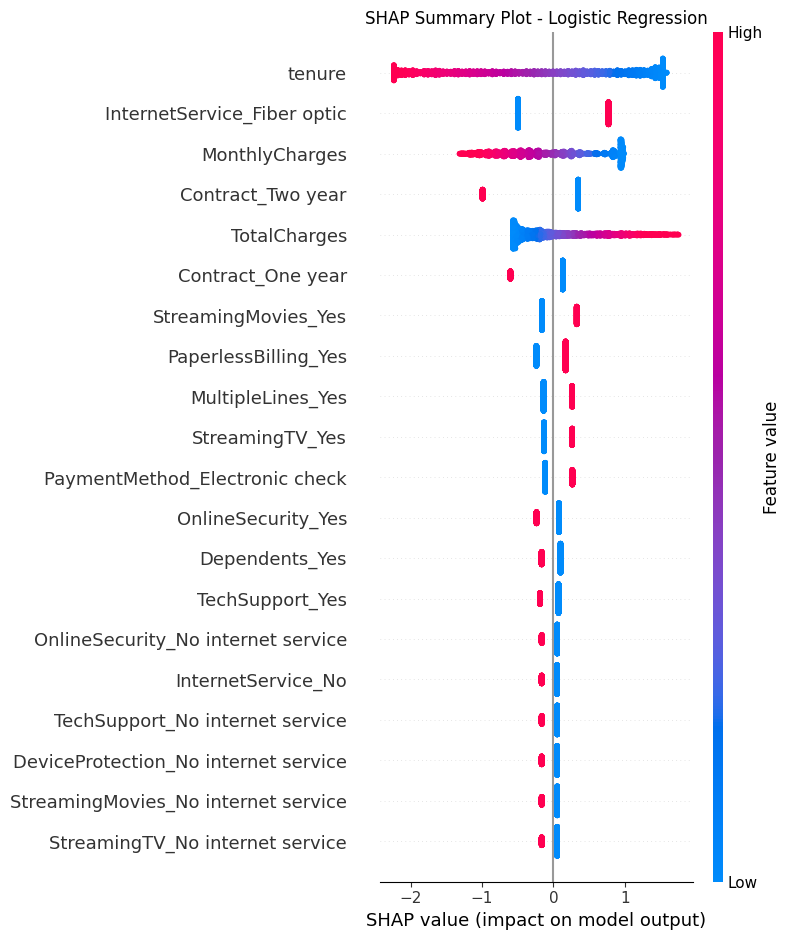


Top 10 признаков по важности SHAP:
                        Feature  Importance
1                        tenure    1.142818
10  InternetService_Fiber optic    0.615207
2                MonthlyCharges    0.614964
25            Contract_Two year    0.501245
3                  TotalCharges    0.489926
24            Contract_One year    0.229678
23          StreamingMovies_Yes    0.224395
26         PaperlessBilling_Yes    0.198803
9             MultipleLines_Yes    0.189395
21              StreamingTV_Yes    0.178709


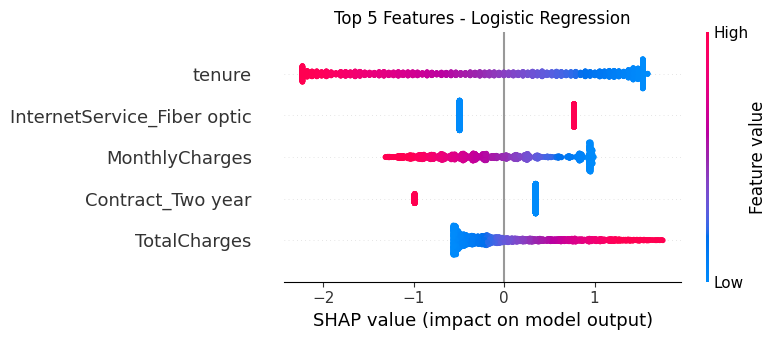

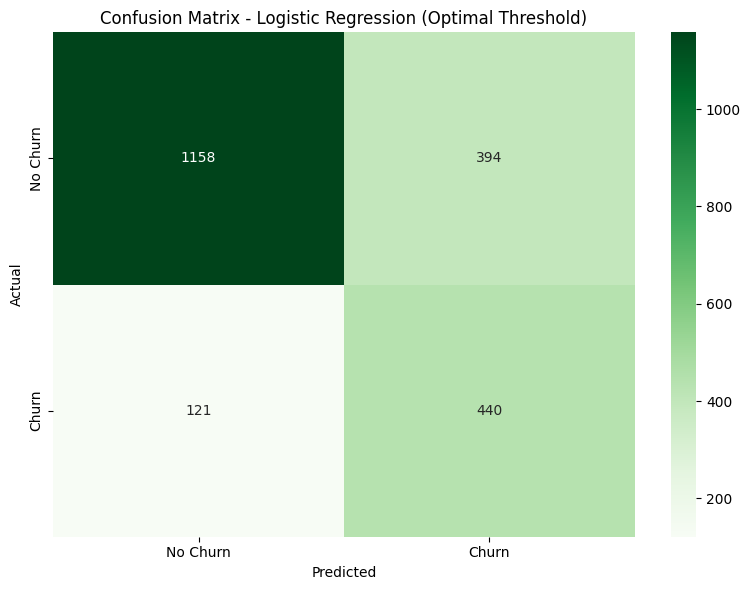

In [11]:
best_model = models[best_model_name]

if best_model_name == 'Logistic Regression':
    explainer = shap.LinearExplainer(best_model, X_train_scaled)
    shap_values = explainer.shap_values(X_test_scaled)
else:
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_test)[1]

shap.summary_plot(shap_values, X_test, show=False)
plt.title(f'SHAP Summary Plot - {best_model_name}')
plt.tight_layout()
plt.show()

feature_importance = np.abs(shap_values).mean(axis=0)
feature_names = X_test.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

print("\nTop 10 признаков по важности SHAP:")
print(importance_df.head(10))

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, max_display=5, show=False)
plt.title(f'Top 5 Features - {best_model_name}')
plt.tight_layout()
plt.show()

conf_matrix = confusion_matrix(y_test, y_pred_optimal)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - {best_model_name} (Optimal Threshold)')
plt.tight_layout()
plt.show()